# 🕐 PM Pulse - Time Prediction System Demo

## Complete Demonstration of SDLC Time Prediction

---

### 📋 Demo Agenda

1. **System Overview** - Architecture & Workflow
2. **Dataset Preprocessing** - Data cleaning & transformation
3. **Feature Engineering** - Encoding & feature selection
4. **Train/Test Split** - Data division strategy
5. **Model Training** - XGBoost Multi-Output Regressor
6. **Model Evaluation** - Accuracy metrics & validation
7. **Inference Pipeline** - Complete prediction flow
8. **Integration with Risk Analysis** - Final timeline calculation

---

## 🏗️ Part 1: System Architecture Overview

### Application Implementation Path

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                         PM PULSE - TIME PREDICTION FLOW                      │
└─────────────────────────────────────────────────────────────────────────────┘

                              USER INPUT
                                  │
                                  ▼
┌─────────────────────────────────────────────────────────────────────────────┐
│  PROJECT REQUIREMENTS                                                        │
│  • Domain (Finance, Health, Education, E-Commerce)                          │
│  • Team Size & Experience                                                    │
│  • Platform (Web, Mobile, Desktop, IoT)                                     │
│  • Budget & Requirements Clarity                                            │
└─────────────────────────────────────────────────────────────────────────────┘
                                  │
                    ┌─────────────┴─────────────┐
                    ▼                           ▼
         ┌──────────────────┐        ┌──────────────────┐
         │  RISK ANALYSIS   │        │    COMPLEXITY    │
         │   (XGBoost)      │        │  (Random Forest) │
         │                  │        │                  │
         │  Output: Risk    │        │  Output:         │
         │  Low/Med/High    │        │  Low/Med/High/   │
         │                  │        │  Very High       │
         └────────┬─────────┘        └────────┬─────────┘
                  │                           │
                  │                           ▼
                  │              ┌──────────────────────┐
                  │              │  SDLC TIME PREDICTION │
                  │              │  (XGBoost Regressor)  │
                  │              │                       │
                  │              │  Input: Features +    │
                  │              │         Complexity    │
                  │              │                       │
                  │              │  Output: Days for     │
                  │              │  each SDLC phase      │
                  │              └───────────┬───────────┘
                  │                          │
                  └────────────┬─────────────┘
                               ▼
                  ┌──────────────────────────┐
                  │   RISK-ADJUSTED TIMELINE │
                  │        (GPT-4 AI)        │
                  │                          │
                  │  • Delays per phase      │
                  │  • Mitigation savings    │
                  │  • Final timeline        │
                  └──────────────────────────┘
                               │
                               ▼
                  ┌──────────────────────────┐
                  │     FINAL OUTPUT         │
                  │  Complete Project        │
                  │  Timeline Report         │
                  └──────────────────────────┘
```

---

## 📦 Part 2: Import Required Libraries

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ All libraries imported successfully!")
print(f"📍 Working Directory: {os.getcwd()}")

Matplotlib is building the font cache; this may take a moment.


✅ All libraries imported successfully!
📍 Working Directory: /Users/kavinduperera/Downloads/R2/pm-pulse/pm-pulse/pm-pulse-FE/backend


---

## 📊 Part 3: Dataset Loading & Exploration

In [2]:
# Load the dataset
print("="*60)
print("📂 LOADING DATASET")
print("="*60)

df_raw = pd.read_csv('data/project_details_v2.csv')

print(f"\n✅ Dataset loaded successfully!")
print(f"📊 Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"\n📋 Columns:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"   {i:2d}. {col}")

📂 LOADING DATASET

✅ Dataset loaded successfully!
📊 Shape: 668 rows × 19 columns

📋 Columns:
    1. Project ID
    2. Start Date
    3. Domain
    4. Expected Team Size
    5. Team Experience
    6. Web
    7. Mobile
    8. IoT
    9. Desktop
   10. Requirement specifity
   11. Expected Budget
   12. Complexity
   13. Planning
   14. Design
   15. Requirements Analysis
   16. Coding
   17. Testing
   18. Deployment
   19. Maintenance


In [ ]:
# Display first few rows
print("\n📋 First 5 rows of the dataset:")
df_raw.head()

In [ ]:
# Dataset Info
print("\n📊 Dataset Information:")
print("="*60)
df_raw.info()

---

## 🧹 Part 4: Data Preprocessing

### Step 4.1: Identify Input and Output Columns

In [3]:
# Define column categories
print("="*60)
print("📋 COLUMN CATEGORIZATION")
print("="*60)

# Columns to drop (not needed for prediction)
drop_columns = ['Project ID', 'Start Date']

# Input Features (X)
input_columns = [
    'Domain',                 # Categorical: Finance, Health, Education, E-Commerce
    'Expected Team Size',     # Numerical: Number of team members
    'Team Experience',        # Categorical: Low, Medium, High
    'Web',                    # Binary: 0 or 1
    'Mobile',                 # Binary: 0 or 1
    'IoT',                    # Binary: 0 or 1
    'Desktop',                # Binary: 0 or 1
    'Requirement specifity',  # Categorical: Vague, Moderate, Well defined
    'Expected Budget',        # Numerical: Budget in USD
    'Complexity'              # Categorical: Low, Medium, High, Very High
]

# Output Targets (Y) - SDLC Phases in Days
output_columns = [
    'Planning',               # Days for planning phase
    'Design',                 # Days for design phase
    'Requirements Analysis',  # Days for requirements analysis
    'Coding',                 # Days for development
    'Testing',                # Days for testing
    'Deployment',             # Days for deployment
    'Maintenance'             # Days for maintenance
]

print("\n🔹 INPUT FEATURES (10 features):")
for i, col in enumerate(input_columns, 1):
    print(f"   {i:2d}. {col}")

print("\n🔹 OUTPUT TARGETS (7 SDLC phases):")
for i, col in enumerate(output_columns, 1):
    print(f"   {i}. {col}")

📋 COLUMN CATEGORIZATION

🔹 INPUT FEATURES (10 features):
    1. Domain
    2. Expected Team Size
    3. Team Experience
    4. Web
    5. Mobile
    6. IoT
    7. Desktop
    8. Requirement specifity
    9. Expected Budget
   10. Complexity

🔹 OUTPUT TARGETS (7 SDLC phases):
   1. Planning
   2. Design
   3. Requirements Analysis
   4. Coding
   5. Testing
   6. Deployment
   7. Maintenance


### Step 4.2: Data Cleaning

In [4]:
print("="*60)
print("🧹 DATA CLEANING")
print("="*60)

# Create a copy for preprocessing
df = df_raw.copy()

# Step 1: Drop unnecessary columns
print("\n📌 Step 1: Dropping unnecessary columns...")
df = df.drop(columns=drop_columns, errors='ignore')
print(f"   ✅ Dropped: {drop_columns}")

# Step 2: Clean Budget column (remove commas and convert to float)
print("\n📌 Step 2: Cleaning 'Expected Budget' column...")
print(f"   Before: {df['Expected Budget'].iloc[0]} (type: {type(df['Expected Budget'].iloc[0])})")
df['Expected Budget'] = df['Expected Budget'].str.replace(',', '').astype(float)
print(f"   After:  {df['Expected Budget'].iloc[0]} (type: {type(df['Expected Budget'].iloc[0])})")

# Step 3: Check for missing values
print("\n📌 Step 3: Checking for missing values...")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values found!")
else:
    print(f"   ⚠️ Missing values:\n{missing[missing > 0]}")

# Step 4: Check data types
print("\n📌 Step 4: Data types after cleaning:")
for col in df.columns:
    print(f"   {col:25s}: {df[col].dtype}")

🧹 DATA CLEANING

📌 Step 1: Dropping unnecessary columns...
   ✅ Dropped: ['Project ID', 'Start Date']

📌 Step 2: Cleaning 'Expected Budget' column...
   Before: 150,000.00 (type: <class 'str'>)
   After:  150000.0 (type: <class 'numpy.float64'>)

📌 Step 3: Checking for missing values...
   ✅ No missing values found!

📌 Step 4: Data types after cleaning:
   Domain                   : object
   Expected Team Size       : int64
   Team Experience          : object
   Web                      : int64
   Mobile                   : int64
   IoT                      : int64
   Desktop                  : int64
   Requirement specifity    : object
   Expected Budget          : float64
   Complexity               : object
   Planning                 : int64
   Design                   : int64
   Requirements Analysis    : int64
   Coding                   : int64
   Testing                  : int64
   Deployment               : int64
   Maintenance              : int64


### Step 4.3: Exploratory Data Analysis (EDA)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("="*60)
print("📊 EXPLORATORY DATA ANALYSIS")
print("="*60)

# Categorical columns distribution
categorical_cols = ['Domain', 'Team Experience', 'Requirement specifity', 'Complexity']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold')

for idx, col in enumerate(categorical_cols):
    ax = axes[idx // 2, idx % 2]
    value_counts = df[col].value_counts()
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(value_counts)))
    bars = ax.bar(value_counts.index, value_counts.values, color=colors, edgecolor='black')
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, val in zip(bars, value_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                str(val), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

📊 EXPLORATORY DATA ANALYSIS


NameError: name 'plt' is not defined

In [ ]:
# SDLC Phases Distribution
print("\n📊 SDLC Phase Time Distribution:")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribution of SDLC Phase Durations (Days)', fontsize=16, fontweight='bold')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']

for idx, col in enumerate(output_columns):
    ax = axes[idx // 4, idx % 4]
    value_counts = df[col].value_counts().sort_index()
    ax.bar(value_counts.index.astype(str), value_counts.values, color=colors[idx], edgecolor='black')
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Days')
    ax.set_ylabel('Count')

# Hide the last empty subplot
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

# Print statistics
print("\n📈 SDLC Phase Statistics:")
print(df[output_columns].describe())

### Step 4.4: Outlier Detection & Visualization

📊 OUTLIER DETECTION - SDLC PHASE DURATIONS


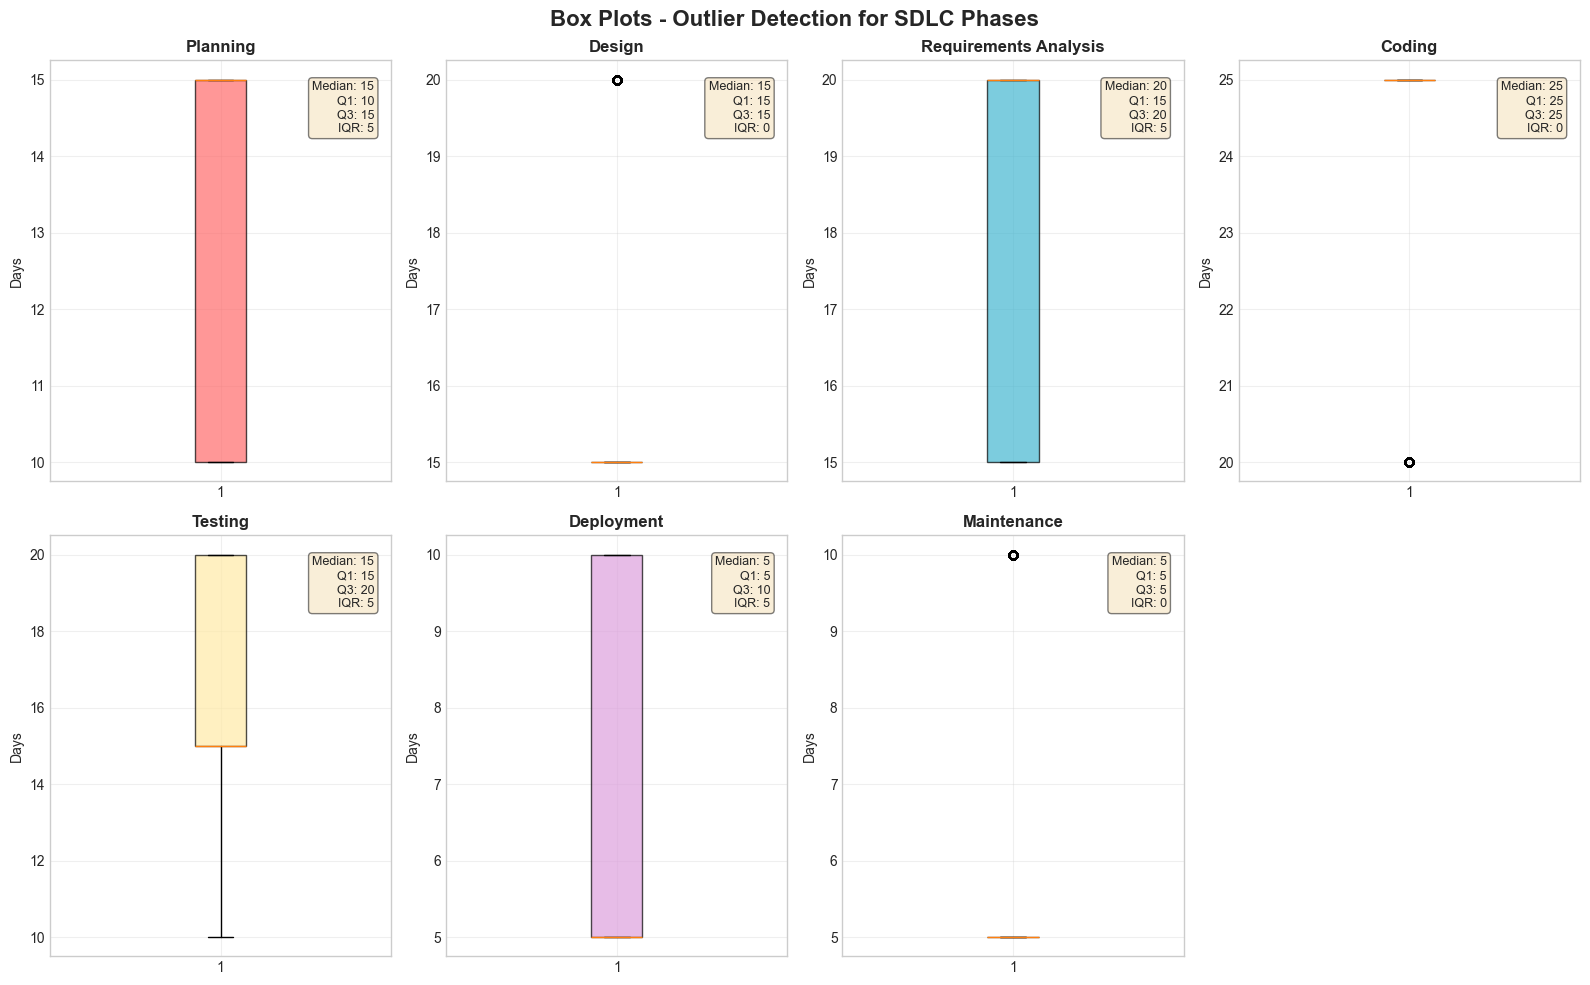


📋 OUTLIER SUMMARY (IQR Method):
------------------------------------------------------------
   Planning                 : 0 outliers (bounds: 2.5 - 22.5)
   Design                   : 150 outliers (bounds: 15.0 - 15.0)
   Requirements Analysis    : 0 outliers (bounds: 7.5 - 27.5)
   Coding                   : 150 outliers (bounds: 25.0 - 25.0)
   Testing                  : 0 outliers (bounds: 7.5 - 27.5)
   Deployment               : 0 outliers (bounds: -2.5 - 17.5)
   Maintenance              : 150 outliers (bounds: 5.0 - 5.0)


In [5]:
print("="*60)
print("📊 OUTLIER DETECTION - SDLC PHASE DURATIONS")
print("="*60)

# Box plots for SDLC phases to detect outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
fig.suptitle('Box Plots - Outlier Detection for SDLC Phases', fontsize=16, fontweight='bold')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']

for idx, col in enumerate(output_columns):
    ax = axes[idx // 4, idx % 4]
    bp = ax.boxplot(df[col], patch_artist=True, vert=True)
    bp['boxes'][0].set_facecolor(colors[idx])
    bp['boxes'][0].set_alpha(0.7)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Days')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    median = df[col].median()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    ax.text(0.95, 0.95, f'Median: {median:.0f}\nQ1: {q1:.0f}\nQ3: {q3:.0f}\nIQR: {iqr:.0f}', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide the last empty subplot
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

# Print outlier summary using IQR method
print("\n📋 OUTLIER SUMMARY (IQR Method):")
print("-" * 60)
for col in output_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    print(f"   {col:<25}: {len(outliers)} outliers (bounds: {lower_bound:.1f} - {upper_bound:.1f})")


📊 VIOLIN PLOTS - Distribution Shape Analysis


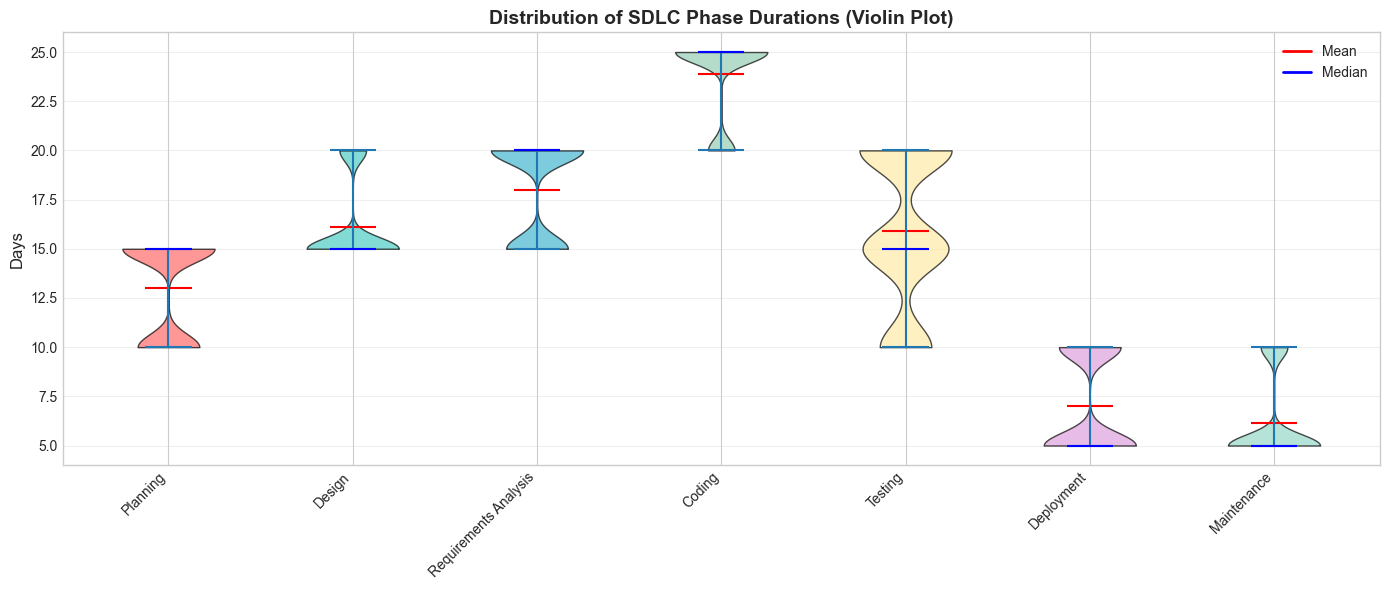

In [6]:
# Violin plots for better distribution visualization
print("\n📊 VIOLIN PLOTS - Distribution Shape Analysis")
print("="*60)

fig, ax = plt.subplots(figsize=(14, 6))

# Create violin plot
parts = ax.violinplot([df[col].values for col in output_columns], 
                       positions=range(1, len(output_columns) + 1),
                       showmeans=True, showmedians=True, showextrema=True)

# Customize colors
for idx, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[idx])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')

parts['cmeans'].set_color('red')
parts['cmedians'].set_color('blue')

ax.set_xticks(range(1, len(output_columns) + 1))
ax.set_xticklabels(output_columns, rotation=45, ha='right')
ax.set_ylabel('Days', fontsize=12)
ax.set_title('Distribution of SDLC Phase Durations (Violin Plot)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='red', lw=2, label='Mean'),
                   Line2D([0], [0], color='blue', lw=2, label='Median')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()


📊 CORRELATION ANALYSIS


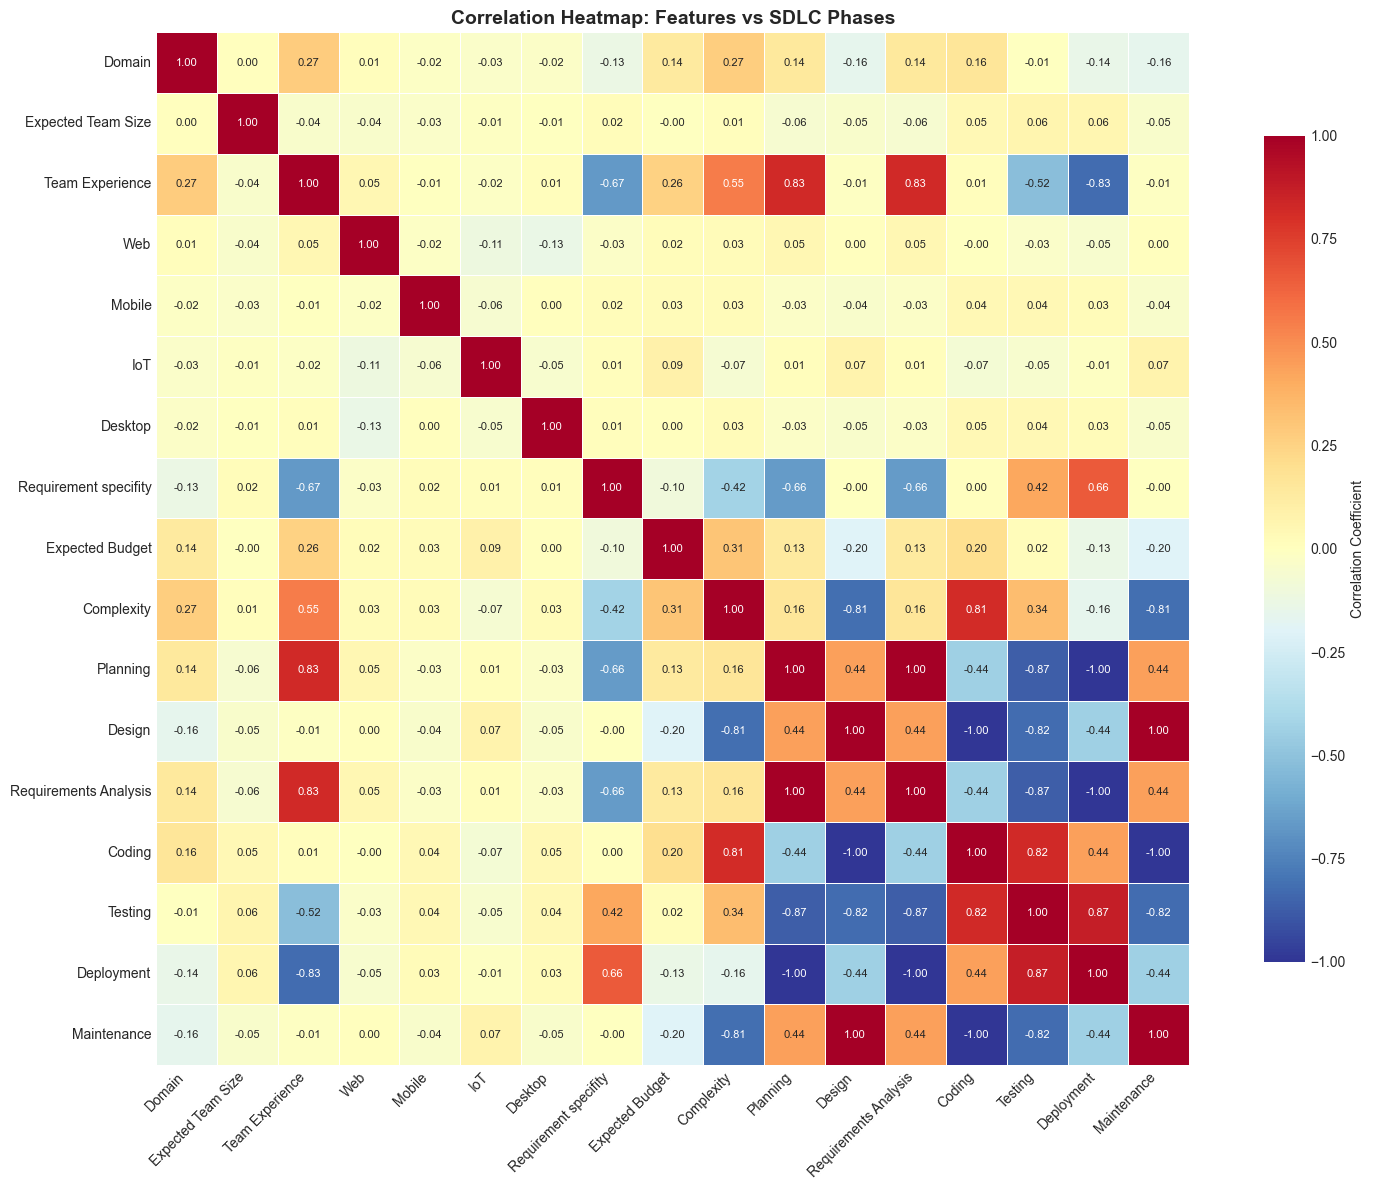


📋 TOP CORRELATIONS WITH SDLC PHASES:
------------------------------------------------------------
   Planning                 : Team Experience (+0.828)
   Design                   : Complexity (-0.815)
   Requirements Analysis    : Team Experience (+0.828)
   Coding                   : Complexity (+0.815)
   Testing                  : Team Experience (-0.519)
   Deployment               : Team Experience (-0.828)
   Maintenance              : Complexity (-0.815)


In [11]:
# Correlation heatmap between input features and SDLC phases
print("\n📊 CORRELATION ANALYSIS")
print("="*60)

# Create encoded dataframe for correlation
df_corr = df_encoded[input_columns + output_columns].copy()

# Calculate correlation matrix
correlation_matrix = df_corr.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(16, 12))
mask = np.zeros_like(correlation_matrix)
mask[np.triu_indices_from(mask, k=1)] = True  # Upper triangle mask

sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlBu_r',
            center=0,
            ax=ax,
            mask=None,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
            annot_kws={'size': 8})

ax.set_title('Correlation Heatmap: Features vs SDLC Phases', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print strongest correlations with SDLC phases
print("\n📋 TOP CORRELATIONS WITH SDLC PHASES:")
print("-" * 60)
for phase in output_columns:
    correlations = correlation_matrix[phase][input_columns].abs().sort_values(ascending=False)
    top_feature = correlations.index[0]
    top_corr = correlation_matrix[phase][top_feature]
    print(f"   {phase:<25}: {top_feature} ({top_corr:+.3f})")


📊 FEATURE IMPACT ON TOTAL PROJECT DURATION


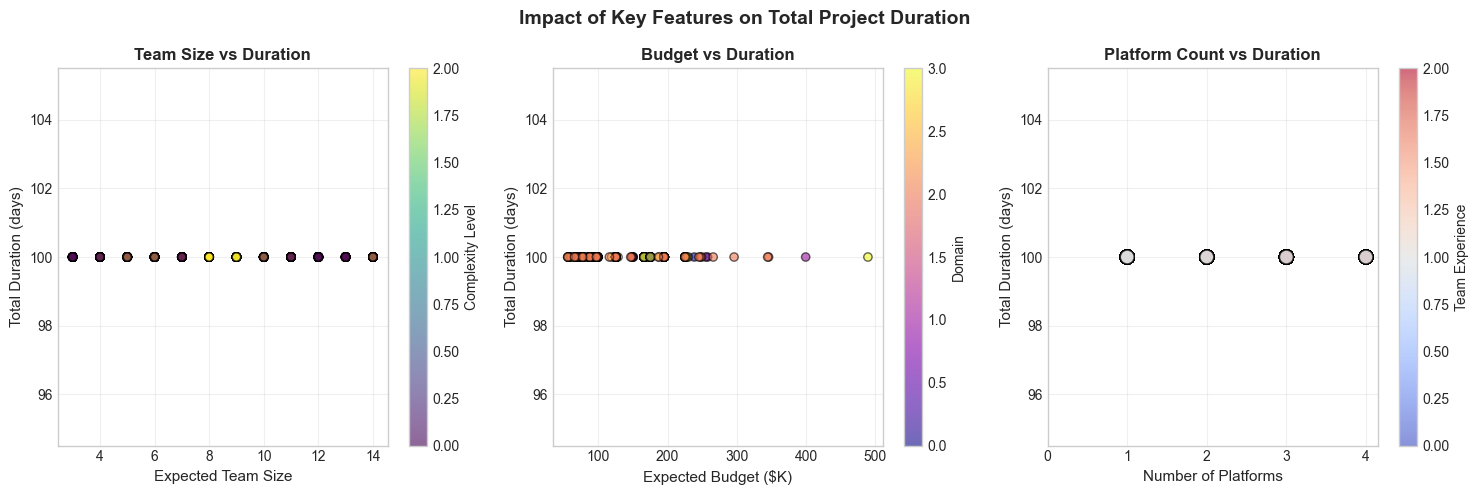

In [12]:
# Scatter plot matrix for numerical features vs Total Time
print("\n📊 FEATURE IMPACT ON TOTAL PROJECT DURATION")
print("="*60)

# Calculate total project duration
df['Total Duration'] = df[output_columns].sum(axis=1)

# Create scatter plots for key numerical features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Impact of Key Features on Total Project Duration', fontsize=14, fontweight='bold')

# 1. Team Size vs Total Duration
ax1 = axes[0]
scatter1 = ax1.scatter(df['Expected Team Size'], df['Total Duration'], 
                       c=df_encoded['Complexity'], cmap='viridis', alpha=0.6, edgecolor='black')
ax1.set_xlabel('Expected Team Size', fontsize=11)
ax1.set_ylabel('Total Duration (days)', fontsize=11)
ax1.set_title('Team Size vs Duration', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Complexity Level')

# 2. Budget vs Total Duration
ax2 = axes[1]
scatter2 = ax2.scatter(df['Expected Budget']/1000, df['Total Duration'], 
                       c=df_encoded['Domain'], cmap='plasma', alpha=0.6, edgecolor='black')
ax2.set_xlabel('Expected Budget ($K)', fontsize=11)
ax2.set_ylabel('Total Duration (days)', fontsize=11)
ax2.set_title('Budget vs Duration', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Domain')

# 3. Platform count vs Total Duration
df['Platform Count'] = df['Web'] + df['Mobile'] + df['Desktop'] + df['IoT']
ax3 = axes[2]
scatter3 = ax3.scatter(df['Platform Count'], df['Total Duration'], 
                       c=df_encoded['Team Experience'], cmap='coolwarm', alpha=0.6, 
                       edgecolor='black', s=100)
ax3.set_xlabel('Number of Platforms', fontsize=11)
ax3.set_ylabel('Total Duration (days)', fontsize=11)
ax3.set_title('Platform Count vs Duration', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xticks([0, 1, 2, 3, 4])
plt.colorbar(scatter3, ax=ax3, label='Team Experience')

plt.tight_layout()
plt.show()

# Clean up temporary column
df.drop(columns=['Total Duration', 'Platform Count'], inplace=True, errors='ignore')

In [ ]:
# Grouped bar chart - SDLC phases by Domain
print("\n📊 SDLC PHASES BY DOMAIN")
print("="*60)

# Calculate mean duration by domain for each phase
domain_means = df.groupby('Domain')[output_columns].mean()

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(output_columns))
width = 0.2
multiplier = 0

domain_colors = {'E- Commerce': '#FF6B6B', 'Education': '#4ECDC4', 
                 'Finance': '#45B7D1', 'Health': '#96CEB4'}

for domain, row in domain_means.iterrows():
    offset = width * multiplier
    bars = ax.bar(x + offset, row.values, width, label=domain, 
                  color=domain_colors.get(domain, 'gray'), edgecolor='black')
    multiplier += 1

ax.set_xlabel('SDLC Phase', fontsize=12)
ax.set_ylabel('Average Duration (days)', fontsize=12)
ax.set_title('Average SDLC Phase Duration by Domain', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(output_columns, rotation=45, ha='right')
ax.legend(title='Domain', loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print table
print("\n📋 Average Duration by Domain (days):")
print(domain_means.round(1).to_string())

---

## 🔧 Part 5: Feature Engineering

### Step 5.1: Label Encoding for Categorical Variables

In [10]:
print("="*60)
print("🔧 FEATURE ENGINEERING - LABEL ENCODING")
print("="*60)

# Identify categorical columns in input features
categorical_input_cols = df[input_columns].select_dtypes(include=['object']).columns.tolist()

print(f"\n📌 Categorical columns to encode: {categorical_input_cols}")

# Create encoder dictionary
encoder_dict = {}

# Create a copy for encoding
df_encoded = df.copy()

print("\n📋 Encoding Mappings:")
print("-" * 50)

for col in categorical_input_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    encoder_dict[col] = le
    
    print(f"\n🔹 {col}:")
    for original, encoded in zip(le.classes_, range(len(le.classes_))):
        print(f"   '{original}' → {encoded}")

print("\n✅ Encoding complete!")

🔧 FEATURE ENGINEERING - LABEL ENCODING

📌 Categorical columns to encode: ['Domain', 'Team Experience', 'Requirement specifity', 'Complexity']

📋 Encoding Mappings:
--------------------------------------------------

🔹 Domain:
   'E- Commerce' → 0
   'Education' → 1
   'Finance' → 2
   'Health' → 3

🔹 Team Experience:
   'High' → 0
   'Low' → 1
   'Medium' → 2

🔹 Requirement specifity:
   'Average' → 0
   'Poor' → 1
   'Well defined' → 2

🔹 Complexity:
   'High' → 0
   'Low' → 1
   'Medium' → 2

✅ Encoding complete!


In [ ]:
# Display encoded data
print("\n📋 Encoded Dataset (first 5 rows):")
df_encoded[input_columns].head()

### Step 5.2: Prepare Feature Matrix (X) and Target Matrix (Y)

In [ ]:
print("="*60)
print("📦 PREPARING FEATURE AND TARGET MATRICES")
print("="*60)

# Feature Matrix (X)
X = df_encoded[input_columns].values

# Target Matrix (Y)
Y = df_encoded[output_columns].values

print(f"\n📊 Feature Matrix (X):")
print(f"   Shape: {X.shape}")
print(f"   Features: {input_columns}")

print(f"\n📊 Target Matrix (Y):")
print(f"   Shape: {Y.shape}")
print(f"   Targets: {output_columns}")

print(f"\n✅ Total samples: {X.shape[0]}")
print(f"✅ Input features: {X.shape[1]}")
print(f"✅ Output targets: {Y.shape[1]}")

---

## ✂️ Part 6: Train/Test Split

### Splitting Strategy: 80% Training, 20% Testing

In [ ]:
print("="*60)
print("✂️ TRAIN/TEST SPLIT")
print("="*60)

# Split parameters
TEST_SIZE = 0.20  # 20% for testing
RANDOM_STATE = 42  # For reproducibility

# Perform split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE
)

print(f"\n📌 Split Configuration:")
print(f"   Test Size: {TEST_SIZE * 100}%")
print(f"   Random State: {RANDOM_STATE}")

print(f"\n📊 Training Set:")
print(f"   X_train shape: {X_train.shape}")
print(f"   Y_train shape: {Y_train.shape}")
print(f"   Samples: {X_train.shape[0]} ({100-TEST_SIZE*100:.0f}%)")

print(f"\n📊 Testing Set:")
print(f"   X_test shape: {X_test.shape}")
print(f"   Y_test shape: {Y_test.shape}")
print(f"   Samples: {X_test.shape[0]} ({TEST_SIZE*100:.0f}%)")

# Visualize split
fig, ax = plt.subplots(figsize=(10, 4))
sizes = [len(X_train), len(X_test)]
labels = [f'Training Set\n{len(X_train)} samples (80%)', f'Testing Set\n{len(X_test)} samples (20%)']
colors = ['#4CAF50', '#2196F3']
explode = (0.02, 0.02)

ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='',
       shadow=True, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax.set_title('Train/Test Data Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 🤖 Part 7: Model Training

### XGBoost Multi-Output Regressor

In [ ]:
print("="*60)
print("🤖 MODEL TRAINING - XGBoost Multi-Output Regressor")
print("="*60)

# Model Configuration
print("\n📌 Model Configuration:")
print("-" * 40)

model_params = {
    'n_estimators': 100,        # Number of boosting rounds
    'max_depth': 6,             # Maximum tree depth
    'learning_rate': 0.1,       # Step size shrinkage
    'subsample': 0.8,           # Subsample ratio of training instances
    'colsample_bytree': 0.8,    # Subsample ratio of columns
    'random_state': 42,
    'n_jobs': -1                # Use all CPU cores
}

for param, value in model_params.items():
    print(f"   {param}: {value}")

# Create base XGBoost regressor
base_model = XGBRegressor(**model_params)

# Wrap with MultiOutputRegressor for multiple targets
model = MultiOutputRegressor(base_model)

print("\n🔄 Training model...")
model.fit(X_train, Y_train)
print("\n✅ Model training complete!")

---

## 📈 Part 8: Model Evaluation

### Comprehensive Accuracy Metrics

In [ ]:
print("="*60)
print("📈 MODEL EVALUATION")
print("="*60)

# Make predictions
Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)

# Calculate overall metrics
print("\n📊 OVERALL PERFORMANCE METRICS:")
print("-" * 50)

metrics = {
    'Metric': ['R² Score', 'RMSE (days)', 'MAE (days)'],
    'Training': [
        f"{r2_score(Y_train, Y_train_pred):.4f}",
        f"{np.sqrt(mean_squared_error(Y_train, Y_train_pred)):.4f}",
        f"{mean_absolute_error(Y_train, Y_train_pred):.4f}"
    ],
    'Testing': [
        f"{r2_score(Y_test, Y_test_pred):.4f}",
        f"{np.sqrt(mean_squared_error(Y_test, Y_test_pred)):.4f}",
        f"{mean_absolute_error(Y_test, Y_test_pred):.4f}"
    ]
}

metrics_df = pd.DataFrame(metrics)
print(metrics_df.to_string(index=False))

In [ ]:
# Per-phase accuracy
print("\n📊 PER-PHASE ACCURACY (Test Set):")
print("-" * 70)
print(f"{'Phase':<25} {'R² Score':>10} {'RMSE':>12} {'MAE':>12}")
print("-" * 70)

phase_metrics = []
for i, phase in enumerate(output_columns):
    r2 = r2_score(Y_test[:, i], Y_test_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_test[:, i], Y_test_pred[:, i]))
    mae = mean_absolute_error(Y_test[:, i], Y_test_pred[:, i])
    print(f"{phase:<25} {r2:>10.4f} {rmse:>10.2f} d {mae:>10.2f} d")
    phase_metrics.append({'Phase': phase, 'R²': r2, 'RMSE': rmse, 'MAE': mae})

print("-" * 70)

In [ ]:
# Visualization: Predicted vs Actual
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Predicted vs Actual - SDLC Phase Durations', fontsize=16, fontweight='bold')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']

for idx, phase in enumerate(output_columns):
    ax = axes[idx // 4, idx % 4]
    ax.scatter(Y_test[:, idx], Y_test_pred[:, idx], alpha=0.5, c=colors[idx], edgecolor='black')
    
    # Perfect prediction line
    min_val = min(Y_test[:, idx].min(), Y_test_pred[:, idx].min())
    max_val = max(Y_test[:, idx].max(), Y_test_pred[:, idx].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect')
    
    ax.set_xlabel('Actual (days)')
    ax.set_ylabel('Predicted (days)')
    ax.set_title(f'{phase}', fontweight='bold')
    ax.legend(loc='lower right')

# Hide the last empty subplot
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Total Project Duration Accuracy
print("\n📊 TOTAL PROJECT DURATION ACCURACY:")
print("-" * 50)

total_actual = Y_test.sum(axis=1)
total_predicted = Y_test_pred.sum(axis=1)

print(f"R² Score:  {r2_score(total_actual, total_predicted):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(total_actual, total_predicted)):.2f} days")
print(f"MAE:       {mean_absolute_error(total_actual, total_predicted):.2f} days")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(total_actual, total_predicted, alpha=0.6, c='#4CAF50', edgecolor='black', s=100)
ax.plot([total_actual.min(), total_actual.max()], 
        [total_actual.min(), total_actual.max()], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Total Duration (days)', fontsize=12)
ax.set_ylabel('Predicted Total Duration (days)', fontsize=12)
ax.set_title('Total Project Duration: Predicted vs Actual', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 💾 Part 9: Save Model & Encoders

In [ ]:
print("="*60)
print("💾 SAVING MODEL AND ENCODERS")
print("="*60)

# Create artifacts directory if not exists
os.makedirs('artifacts', exist_ok=True)

# Save the model
model_path = 'artifacts/xgb_sdlc.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)
print(f"\n✅ Model saved: {model_path}")

# Save the encoder dictionary
encoder_path = 'artifacts/label_encoder_sdlc.pkl'
with open(encoder_path, 'wb') as f:
    pickle.dump(encoder_dict, f)
print(f"✅ Encoders saved: {encoder_path}")

# List all artifacts
print("\n📁 Artifacts Directory:")
for file in os.listdir('artifacts'):
    size = os.path.getsize(f'artifacts/{file}')
    print(f"   📄 {file} ({size/1024:.1f} KB)")

---

## 🔮 Part 10: Inference Pipeline Demo

### Complete Prediction Flow

In [ ]:
print("="*60)
print("🔮 INFERENCE PIPELINE DEMONSTRATION")
print("="*60)

# Sample Project Input
sample_project = {
    "Domain": "Finance",
    "Expected Team Size": 10,
    "Team Experience": "High",
    "Web": 1,
    "Mobile": 1,
    "IoT": 0,
    "Desktop": 0,
    "Requirement specifity": "Well defined",
    "Expected Budget": 150000.00,
    "Complexity": "Medium"  # This comes from complexity prediction model
}

print("\n📋 SAMPLE PROJECT INPUT:")
print("-" * 40)
for key, value in sample_project.items():
    print(f"   {key}: {value}")

In [ ]:
def predict_sdlc_time(project_data, model, encoder_dict, input_columns, output_columns):
    """
    Predict SDLC phase durations for a project.
    
    Parameters:
    -----------
    project_data : dict
        Dictionary containing project features
    model : trained model
        XGBoost multi-output regressor
    encoder_dict : dict
        Label encoders for categorical features
    input_columns : list
        List of input feature names
    output_columns : list
        List of SDLC phase names
    
    Returns:
    --------
    dict : Predicted days for each SDLC phase
    """
    # Step 1: Create DataFrame
    df_input = pd.DataFrame([project_data])
    
    # Step 2: Encode categorical columns
    for col in df_input.select_dtypes(include=['object']).columns:
        if col in encoder_dict:
            df_input[col] = encoder_dict[col].transform(df_input[col])
    
    # Step 3: Select and order columns
    X_input = df_input[input_columns].values
    
    # Step 4: Predict
    predictions = model.predict(X_input).squeeze()
    
    # Step 5: Round and ensure minimum 1 day
    predictions = np.round(predictions).astype(int)
    predictions = np.maximum(predictions, 1)
    
    # Step 6: Create result dictionary
    result = dict(zip(output_columns, predictions))
    
    return result

print("✅ Inference function defined!")

In [ ]:
# Run prediction
print("\n🔄 Running SDLC Time Prediction...")
print("="*60)

predicted_time = predict_sdlc_time(
    project_data=sample_project,
    model=model,
    encoder_dict=encoder_dict,
    input_columns=input_columns,
    output_columns=output_columns
)

print("\n📊 PREDICTED SDLC TIMELINE:")
print("-" * 40)
total_days = 0
for phase, days in predicted_time.items():
    print(f"   {phase:<25}: {days:>3} days")
    total_days += days

print("-" * 40)
print(f"   {'TOTAL DURATION':<25}: {total_days:>3} days")
print(f"   {'Estimated Months':<25}: {total_days/30:.1f} months")

In [ ]:
# Visualize predicted timeline
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
phases = list(predicted_time.keys())
days = list(predicted_time.values())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']

bars = ax1.barh(phases, days, color=colors, edgecolor='black')
ax1.set_xlabel('Days', fontsize=12)
ax1.set_title('Predicted SDLC Phase Durations', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# Add value labels
for bar, d in zip(bars, days):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{d} days', va='center', fontsize=10, fontweight='bold')

# Pie chart
ax2.pie(days, labels=phases, colors=colors, autopct='%1.1f%%', 
        startangle=90, explode=[0.02]*7)
ax2.set_title('Time Distribution by Phase', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---

## 🎯 Part 11: Complete Workflow Summary

### End-to-End Pipeline

In [ ]:
print("="*70)
print("🎯 COMPLETE TIME PREDICTION WORKFLOW SUMMARY")
print("="*70)

workflow_steps = [
    ("1. Data Collection", "Gather historical project data with SDLC phase durations"),
    ("2. Data Preprocessing", "Clean data, handle missing values, format columns"),
    ("3. Feature Engineering", "Encode categorical variables using LabelEncoder"),
    ("4. Train/Test Split", "80% training, 20% testing with random_state=42"),
    ("5. Model Training", "XGBoost MultiOutputRegressor with 100 estimators"),
    ("6. Model Evaluation", "R², RMSE, MAE metrics for each SDLC phase"),
    ("7. Model Persistence", "Save model and encoders as .pkl files"),
    ("8. Inference Pipeline", "Load model, encode input, predict, post-process"),
    ("9. Risk Adjustment", "GPT-4 adjusts timeline based on risk analysis"),
    ("10. Final Output", "Complete project timeline with recommendations")
]

for step, description in workflow_steps:
    print(f"\n📌 {step}")
    print(f"   {description}")

print("\n" + "="*70)
print("✅ DEMO COMPLETE!")
print("="*70)

---

## 📁 Files & Artifacts Reference

| File | Purpose | Location |
|------|---------|----------|
| `project_details_v2.csv` | Training dataset | `data/` |
| `xgb_sdlc.pkl` | Trained XGBoost model | `artifacts/` |
| `label_encoder_sdlc.pkl` | Feature encoders | `artifacts/` |
| `app.py` | Flask API server | `backend/` |

---

## 🔗 API Endpoint

```bash
POST http://localhost:5001/sdlc
Content-Type: application/json

{
    "Domain": "Finance",
    "Expected Team Size": 10,
    "Team Experience": "High",
    "Web": 1,
    "Mobile": 1,
    "IoT": 0,
    "Desktop": 0,
    "Requirement specifity": "Well defined",
    "Expected Budget": 150000,
    "Project Scope": "Medium"
}
```